In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [ ]:
CSV_PATH = "features/features_timeout_15s_2pkts_each_dir.csv"
CSV_PATH = "features/features_timeout_15s_nonvpn.csv"

LABEL_COLUMN = "Label"   # numele coloanei de label
POSITIVE_LABELS = [14, 15, 16, 17]  # label-uri care devin clasa 1

In [33]:
# Read csv
df = pd.read_csv(CSV_PATH)
df["binary_label"] = df[LABEL_COLUMN].isin(POSITIVE_LABELS).astype(int)
X_all = df.drop(columns=[LABEL_COLUMN, "binary_label", 'flow_id'])
X_all = X_all.select_dtypes(include=[np.number])
y = df["binary_label"]

In [34]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Plot 2/3 features

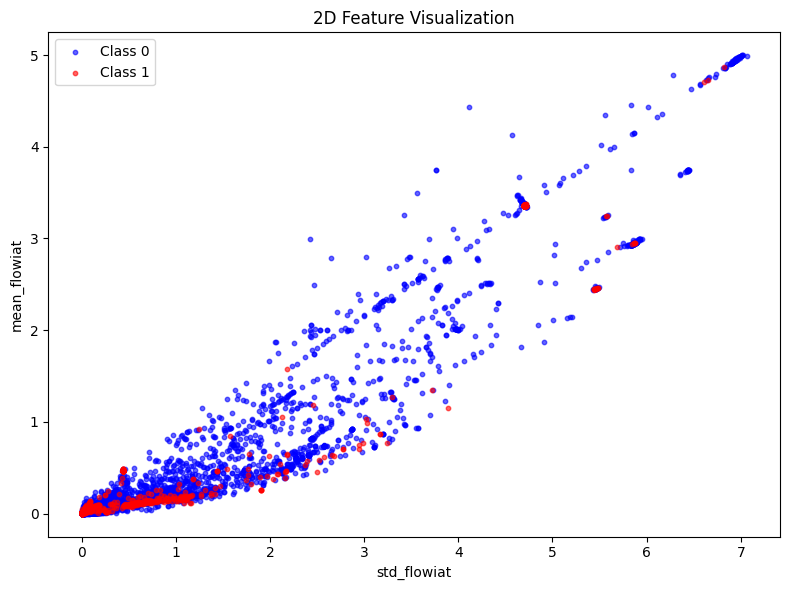

In [36]:
FEATURES_2D = [
    "std_flowiat",
    "mean_flowiat"
]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

for label, color, name in [(0, "blue", "Class 0"), (1, "red", "Class 1")]:
    mask = y == label
    ax.scatter(
        df.loc[mask, FEATURES_2D[0]],
        df.loc[mask, FEATURES_2D[1]],
        c=color,
        label=name,
        alpha=0.6,
        s=10
    )

ax.set_xlabel(FEATURES_2D[0])
ax.set_ylabel(FEATURES_2D[1])
ax.set_title("2D Feature Visualization")
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2 tSNE components

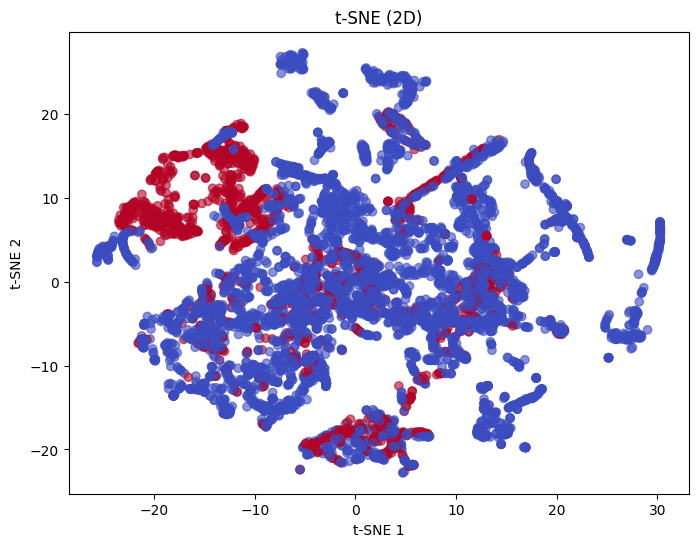

In [29]:
tsne = TSNE(
    n_components=3,
    perplexity=30,
    random_state=42,
    init="pca"
)

X_tsne = tsne.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

scatter = ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.6
)

ax.set_title("t-SNE (2D)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.show()